In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

pd_train = pd.read_csv("../processed_data/plantdoc_train.csv")
pd_val = pd.read_csv("../processed_data/plantdoc_val.csv")
pd_test = pd.read_csv("../processed_data/plantdoc_test.csv")

all_pd = pd.concat([pd_train, pd_val, pd_test])

class_names_pd = sorted(all_pd["class_name"].unique())
num_classes_pd = len(class_names_pd)

print("Classes:", num_classes_pd)
print("Train:", len(pd_train))
print("Validation:", len(pd_val))
print("Test:", len(pd_test))

Classes: 27
Train: 1983
Validation: 351
Test: 236


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(df, training=False):
    paths = df["image_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(df), seed=42)

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


pd_train_ds = make_dataset(pd_train, training=True)
pd_val_ds = make_dataset(pd_val)
pd_test_ds = make_dataset(pd_test)

In [3]:
base_model_pd_mobile = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_pd_mobile.trainable = False

In [4]:
data_augmentation_pd = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation_pd(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model_pd_mobile(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes_pd,
    activation="softmax"
)(x)

pd_mobilenet = keras.Model(inputs, outputs)

pd_mobilenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,571 (8.75 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
pd_mobilenet.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
callbacks_pd_mobile = [
    keras.callbacks.ModelCheckpoint(
        "../Models/plantdoc_mobilenetv2_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        "../report/plantdoc_mobilenetv2_history.csv"
    )
]

In [7]:
import time

start_time = time.time()

pd_mobilenet_history = pd_mobilenet.fit(
    pd_train_ds,
    validation_data=pd_val_ds,
    epochs=25,
    callbacks=callbacks_pd_mobile
)

pd_mobilenet_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{pd_mobilenet_training_time / 60:.2f} minutes"
)

Epoch 1/25


d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.2133 - loss: 2.8164
Epoch 1: val_loss improved from None to 2.10653, saving model to ../Models/plantdoc_mobilenetv2_best.keras

Epoch 1: finished saving model to ../Models/plantdoc_mobilenetv2_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 574ms/step - accuracy: 0.2133 - loss: 2.8164 - val_accuracy: 0.3875 - val_loss: 2.1065 - learning_rate: 0.0010
Epoch 2/25
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.4428 - loss: 1.8646
Epoch 2: val_loss improved from 2.10653 to 1.84406, saving model to ../Models/plantdoc_mobilenetv2_best.keras

Epoch 2: finished saving model to ../Models/plantdoc_mobilenetv2_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 66s 531ms/step - accuracy: 0.4428 - loss: 1.8646 - val_accuracy: 0.4672 - val_loss: 1.8441 - learning_rate: 0.0010
Epoch 3/25
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5018 - loss: 1.5926
Epoch 3: val_loss improved from 1.84406 to 1.72924, saving model to ../Models/plantdoc_m

In [8]:
best_pd_mobilenet = keras.models.load_model(
    "../Models/plantdoc_mobilenetv2_best.keras"
)

pd_mobile_test_loss, pd_mobile_test_accuracy = (
    best_pd_mobilenet.evaluate(pd_test_ds)
)

print("PlantDoc MobileNetV2 Test Loss:", pd_mobile_test_loss)
print("PlantDoc MobileNetV2 Test Accuracy:", pd_mobile_test_accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.4619 - loss: 1.7129
PlantDoc MobileNetV2 Test Loss: 1.7128620147705078
PlantDoc MobileNetV2 Test Accuracy: 0.4618644118309021


In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

y_true_pd_mobile = np.concatenate([
    y.numpy() for x, y in pd_test_ds
])

y_prob_pd_mobile = best_pd_mobilenet.predict(pd_test_ds)

y_pred_pd_mobile = np.argmax(
    y_prob_pd_mobile,
    axis=1
)

pd_mobile_report = classification_report(
    y_true_pd_mobile,
    y_pred_pd_mobile,
    target_names=class_names_pd,
    digits=4,
    output_dict=True
)

pd_mobile_report_df = pd.DataFrame(
    pd_mobile_report
).transpose()

pd_mobile_report_df.to_csv(
    "../report/plantdoc_mobilenetv2_classification_report.csv"
)

pd_mobile_report_df

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 400ms/step


d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

,precision,recall,f1-score,support
Apple Scab Leaf,0.166667,0.400000,0.235294,10.000000
Apple leaf,0.500000,0.666667,0.571429,9.000000
Apple rust leaf,0.555556,0.500000,0.526316,10.000000
Bell_pepper leaf,0.000000,0.000000,0.000000,8.000000
Bell_pepper leaf spot,0.300000,0.333333,0.315789,9.000000
Blueberry leaf,0.333333,0.454545,0.384615,11.000000
Cherry leaf,0.666667,0.200000,0.307692,10.000000
Corn Gray leaf spot,0.250000,0.500000,0.333333,4.000000
Corn leaf blight,0.833333,0.416667,0.555556,12.000000
Corn rust leaf,0.750000,0.900000,0.818182,10.000000


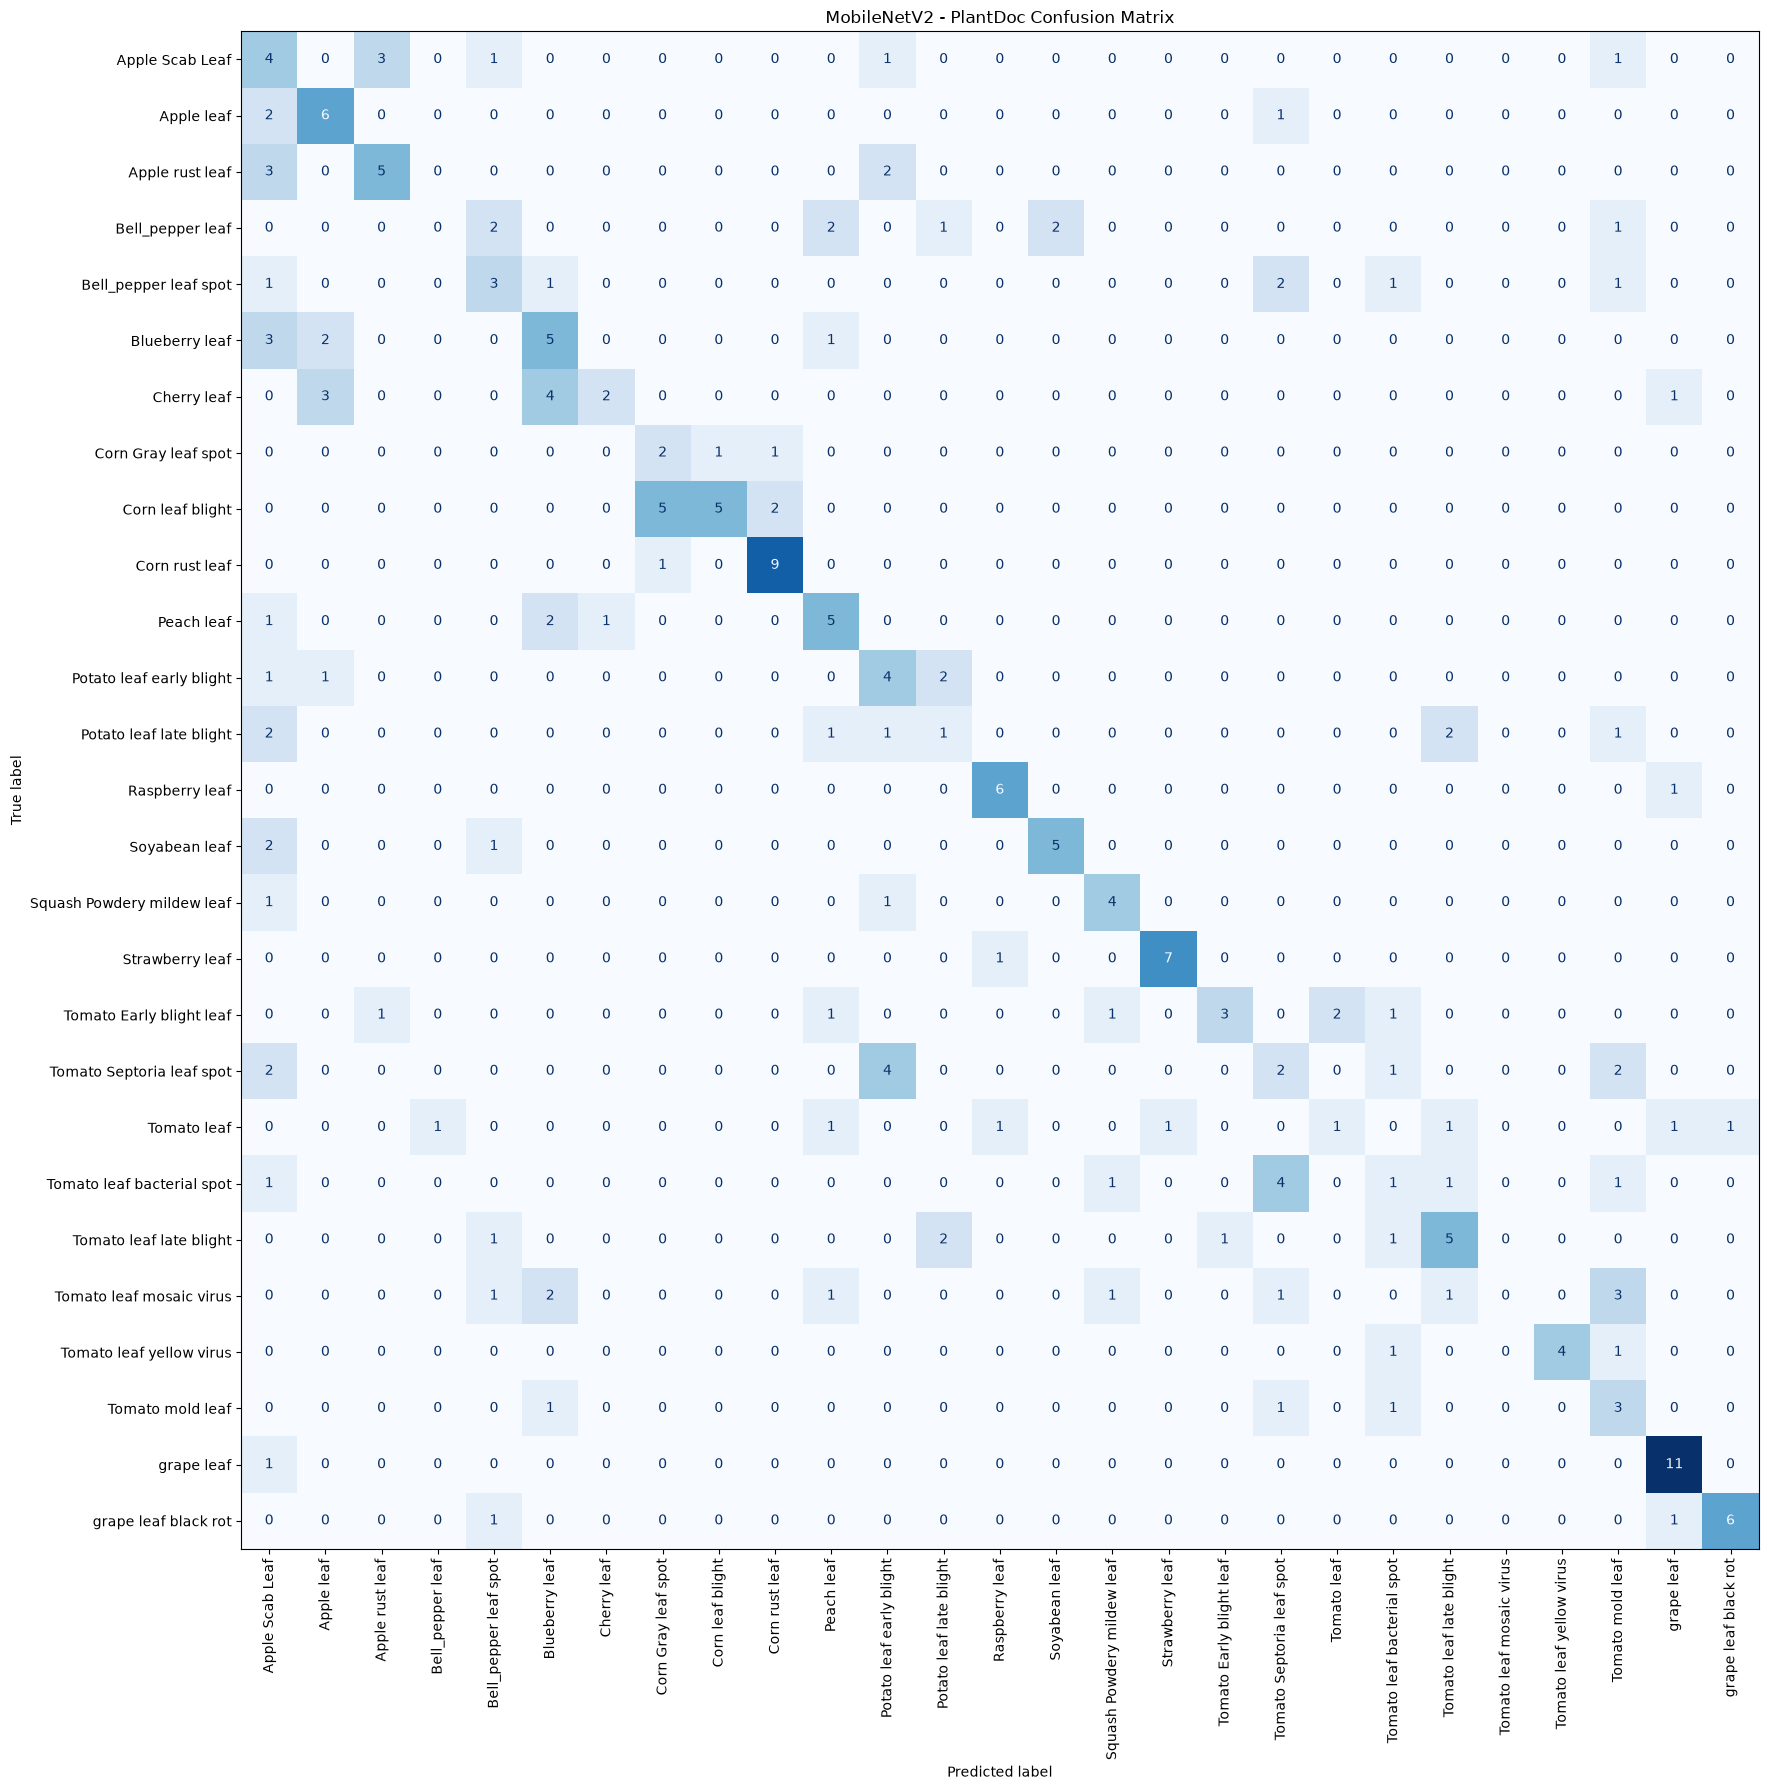

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_pd_mobile = confusion_matrix(
    y_true_pd_mobile,
    y_pred_pd_mobile
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pd_mobile,
    display_labels=class_names_pd
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("MobileNetV2 - PlantDoc Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../report/plantdoc_mobilenetv2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
mobile_pd_history_df = pd.read_csv(
    "../report/plantdoc_mobilenetv2_history.csv"
)

mobile_pd_history_df["epoch_number"] = range(
    1,
    len(mobile_pd_history_df) + 1
)

print("Completed epochs:", len(mobile_pd_history_df))
mobile_pd_history_df

Completed epochs: 17


,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss,epoch_number
0,0,0.213313,0.00100,2.816401,0.387464,2.106526,1
1,1,0.442763,0.00100,1.864596,0.467236,1.844061,2
2,2,0.501765,0.00100,1.592620,0.458689,1.729245,3
3,3,0.553707,0.00100,1.458677,0.504274,1.648066,4
4,4,0.587494,0.00100,1.299244,0.472934,1.695546,5
5,5,0.612204,0.00100,1.248879,0.490029,1.650545,6
6,6,0.652042,0.00050,1.094475,0.492877,1.597471,7
7,7,0.681795,0.00050,1.054969,0.498576,1.628794,8
8,8,0.679274,0.00050,1.040923,0.518519,1.582090,9
9,9,0.689864,0.00050,0.984343,0.529915,1.563648,10


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

mobile_pd_history_df = pd.read_csv(
    "../report/plantdoc_mobilenetv2_history.csv"
)

mobile_pd_history_df["epoch_number"] = range(
    1, len(mobile_pd_history_df) + 1
)

print("Completed epochs:", len(mobile_pd_history_df))
mobile_pd_history_df

Completed epochs: 17


,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss,epoch_number
0,0,0.213313,0.00100,2.816401,0.387464,2.106526,1
1,1,0.442763,0.00100,1.864596,0.467236,1.844061,2
2,2,0.501765,0.00100,1.592620,0.458689,1.729245,3
3,3,0.553707,0.00100,1.458677,0.504274,1.648066,4
4,4,0.587494,0.00100,1.299244,0.472934,1.695546,5
5,5,0.612204,0.00100,1.248879,0.490029,1.650545,6
6,6,0.652042,0.00050,1.094475,0.492877,1.597471,7
7,7,0.681795,0.00050,1.054969,0.498576,1.628794,8
8,8,0.679274,0.00050,1.040923,0.518519,1.582090,9
9,9,0.689864,0.00050,0.984343,0.529915,1.563648,10


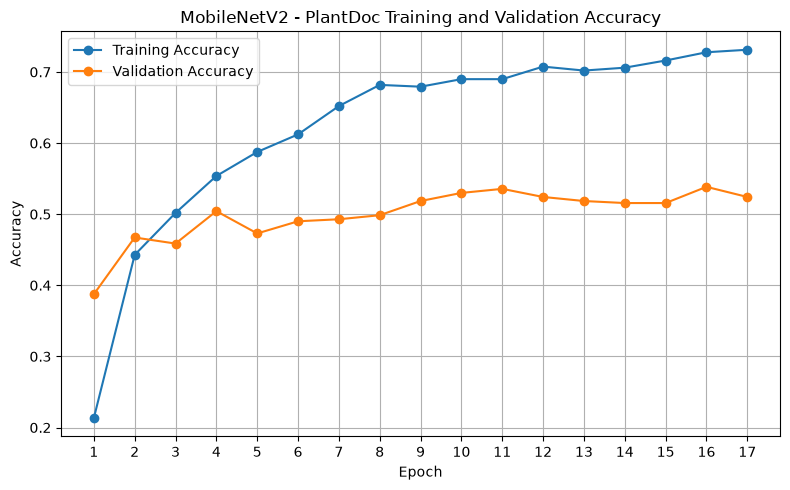

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobile_pd_history_df["epoch_number"],
    mobile_pd_history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    mobile_pd_history_df["epoch_number"],
    mobile_pd_history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - PlantDoc Training and Validation Accuracy")

plt.xticks(mobile_pd_history_df["epoch_number"])
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../report/plantdoc_mobilenetv2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

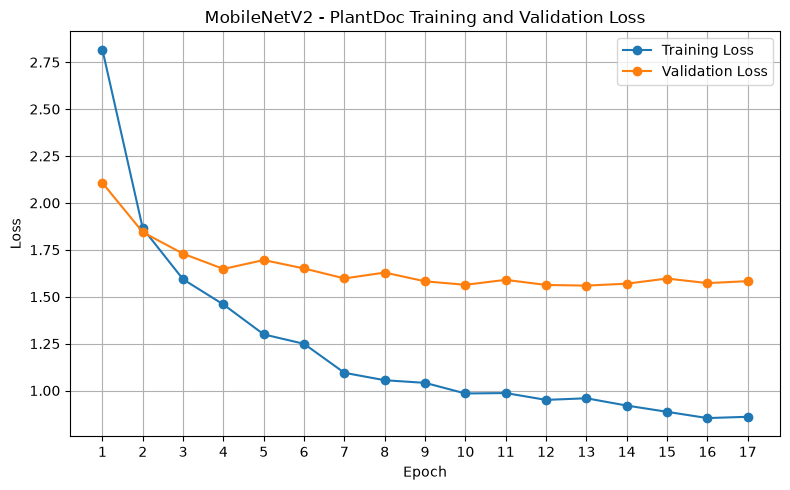

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobile_pd_history_df["epoch_number"],
    mobile_pd_history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    mobile_pd_history_df["epoch_number"],
    mobile_pd_history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - PlantDoc Training and Validation Loss")

plt.xticks(mobile_pd_history_df["epoch_number"])
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../report/plantdoc_mobilenetv2_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()